# 04 — Impact métier : du score à la décision

Un modèle de churn ne vaut que par la **décision** qu'il permet : à qui proposer une offre de
rétention ? Chaque erreur a un coût différent :

| | Client ciblé | Client non ciblé |
|---|---|---|
| **Va partir** | VP : `acceptation × valeur − coût offre` | FN : 0 vs « ne rien faire », mais valeur perdue |
| **Va rester** | FP : `− coût offre` (remise offerte pour rien) | VN : 0 |

avec `valeur = MonthlyCharges × 12` (revenu d'un an). Hypothèses par défaut (`churn.config`) :
offre à 50 €, 30 % des churners ciblés restent. Ces chiffres sont des **hypothèses** : on teste
plus bas la sensibilité des conclusions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import FIGURES_DIR

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.4f}".format)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


In [2]:
import joblib
from sklearn.model_selection import cross_val_predict
from churn.config import BUSINESS, MODEL_PATH, BusinessAssumptions
from churn.data import load, train_test
from churn.evaluate import (customer_value, lift_table, optimal_threshold, profit_curve,
                            strategy_comparison)
from churn.train import calibrated, make_cv

artifact = joblib.load(MODEL_PATH)
X_train, X_test, y_train, y_test = train_test(load())
p_test = artifact["model"].predict_proba(X_test)[:, 1]
v_test = customer_value(X_test["MonthlyCharges"])
thr = artifact["threshold"]

# Probabilités out-of-fold du train : c'est sur elles (et non sur le test) qu'on choisit le seuil.
cv = make_cv()
p_oof = cross_val_predict(calibrated(artifact["model_name"], artifact["params"], cv),
                          X_train, y_train, cv=cv, method="predict_proba")[:, 1]
v_train = customer_value(X_train["MonthlyCharges"])
print(f"Seuil métier (choisi sur OOF train) : {thr:.2f}")

Seuil métier (choisi sur OOF train) : 0.17


## Courbe de profit

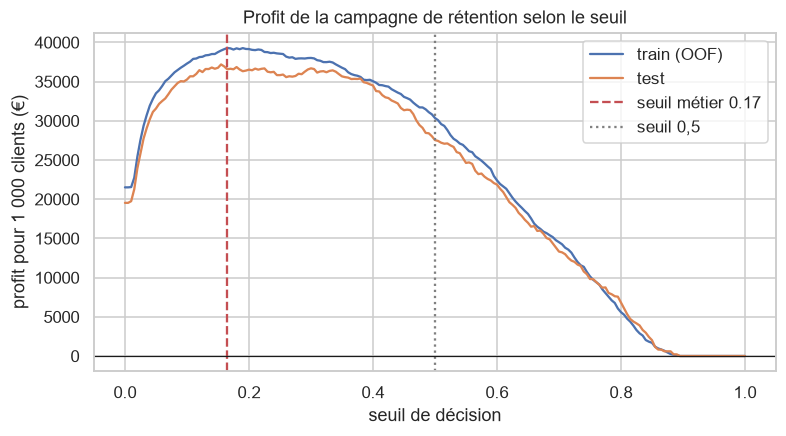

In [3]:
curve_test = profit_curve(y_test, p_test, v_test)
curve_oof = profit_curve(y_train, p_oof, v_train)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_oof["threshold"], curve_oof["profit"] / len(y_train) * 1000, label="train (OOF)")
ax.plot(curve_test["threshold"], curve_test["profit"] / len(y_test) * 1000, label="test")
ax.axvline(thr, color="#C44E52", ls="--", label=f"seuil métier {thr:.2f}")
ax.axvline(0.5, color="grey", ls=":", label="seuil 0,5")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("seuil de décision"); ax.set_ylabel("profit pour 1 000 clients (€)")
ax.set_title("Profit de la campagne de rétention selon le seuil"); ax.legend()
save(fig, "04_profit_curve")

In [4]:
strategies = strategy_comparison(y_test, p_test, v_test, thr)
strategies["profit / 1000 clients"] = strategies["profit"] / len(y_test) * 1000
strategies["profit annualisé (base 7 043)"] = strategies["profit"] / len(y_test) * 7043
strategies.set_index("strategie")

,n_cibles,churners_cibles,profit,profit / 1000 clients,profit annualisé (base 7 043)
strategie,,,,,
Aucune action,0,0,0.0000,0.0000,0.0000
Cibler tout le monde,1409,374,27523.6400,19534.1661,137579.1317
Modèle (seuil métier),721,329,51526.6600,36569.6664,257560.1607
Modèle (seuil 0.5),293,191,38807.8400,27542.8247,193984.1144
Oracle (churners connus),374,374,79273.6400,56262.3421,396255.6753


Le seuil qui maximise le profit est **bien plus bas que 0,5** : un faux positif ne coûte que
l'offre (50 €) alors qu'un churner retenu rapporte en moyenne bien plus. Il vaut donc mieux
cibler large. Le seuil 0,5 « par défaut » laisse une part importante du gain sur la table, et
arroser tous les clients gaspille l'essentiel du budget en offres données à des clients fidèles.
L'oracle (connaître les churners à l'avance) donne le plafond théorique.

## Lift : concentration du risque

,decile,n,churners,p_moy,taux_churn,lift,part_churners_cumulee
0,1,141,106,0.7539,0.7518,2.8322,0.2834
1,2,141,81,0.5835,0.5745,2.1642,0.5000
2,3,141,68,0.4536,0.4823,1.8169,0.6818
3,4,141,39,0.3316,0.2766,1.0420,0.7861
4,5,141,32,0.2242,0.2270,0.8550,0.8717
5,6,140,24,0.1382,0.1714,0.6458,0.9358
6,7,141,12,0.0828,0.0851,0.3206,0.9679
7,8,141,10,0.0491,0.0709,0.2672,0.9947
8,9,141,0,0.0272,0.0000,0.0000,0.9947
9,10,141,2,0.0157,0.0142,0.0534,1.0000


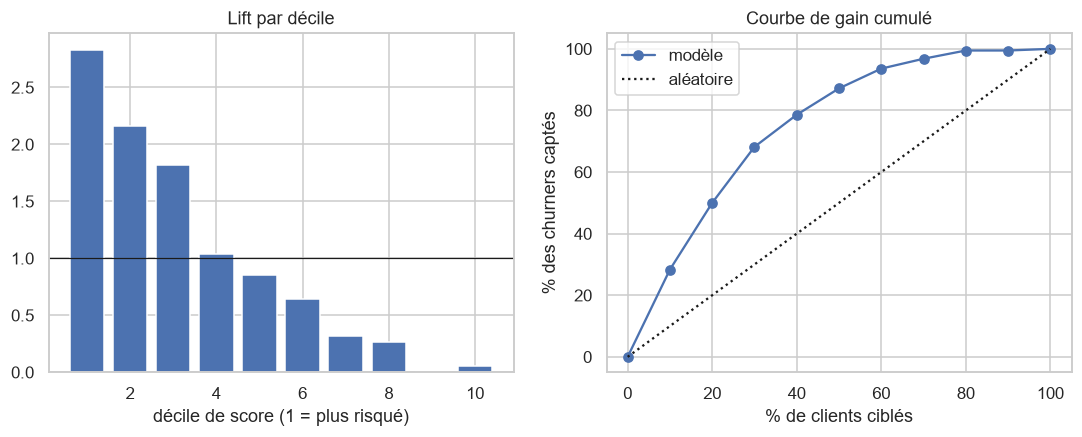

In [5]:
lift = lift_table(y_test, p_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(lift["decile"], lift["lift"], color="#4C72B0"); axes[0].axhline(1, color="k", lw=0.8)
axes[0].set_xlabel("décile de score (1 = plus risqué)"); axes[0].set_title("Lift par décile")
axes[1].plot(np.r_[0, lift["decile"] * 10], np.r_[0, lift["part_churners_cumulee"]] * 100, marker="o", label="modèle")
axes[1].plot([0, 100], [0, 100], "k:", label="aléatoire")
axes[1].set_xlabel("% de clients ciblés"); axes[1].set_ylabel("% des churners captés")
axes[1].set_title("Courbe de gain cumulé"); axes[1].legend()
save(fig, "04_lift_gain")
lift

## Sensibilité aux hypothèses

Pour chaque scénario (coût de l'offre × taux d'acceptation), on **re-choisit le seuil sur l'OOF
du train** puis on mesure le profit sur le test — exactement ce que ferait l'équipe marketing en
changeant d'offre.

,coût offre,acceptation,seuil optimal,profit modèle,"profit seuil 0,5",profit tout le monde
0,20,0.1000,0.2150,15007.8200,11959.2800,4477.8800
1,20,0.2000,0.1100,44631.7200,29778.5600,37135.7600
2,20,0.3000,0.0650,75658.3600,47597.8400,69793.6400
3,20,0.5000,0.0500,140820.6000,83236.4000,135109.4000
4,50,0.1000,0.5150,3451.8200,3169.2800,-37792.1200
5,50,0.2000,0.3350,26141.4800,20988.5600,-5134.2400
6,50,0.3000,0.1650,51526.6600,38807.8400,27523.6400
7,50,0.5000,0.1100,111579.3000,74446.4000,92839.4000
8,100,0.1000,0.8800,30.7200,-11480.7200,-108242.1200
9,100,0.2000,0.5150,6903.6400,6338.5600,-75584.2400


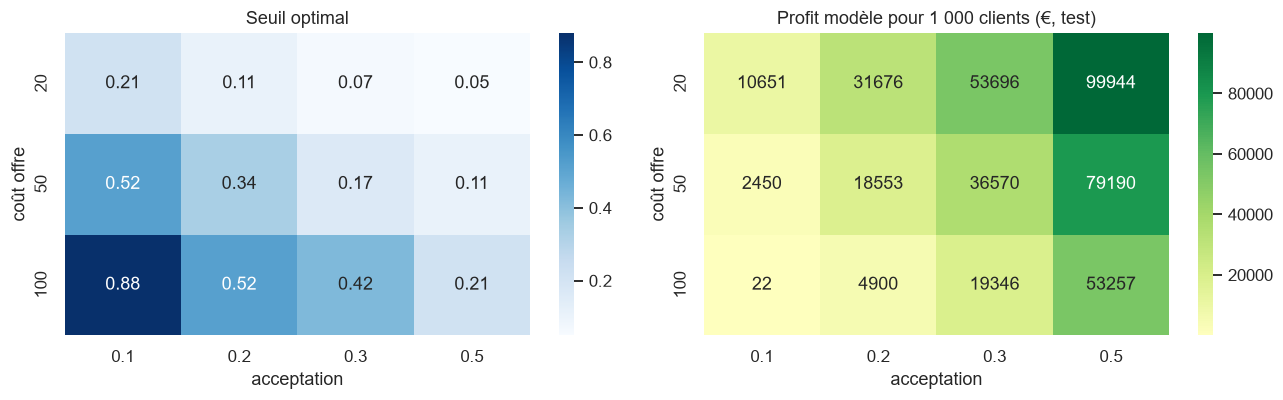

In [6]:
rows = []
for cost in [20, 50, 100]:
    for acc in [0.1, 0.2, 0.3, 0.5]:
        a = BusinessAssumptions(clv_months=12, offer_cost=cost, acceptance_rate=acc)
        t, _ = optimal_threshold(y_train, p_oof, v_train, a)
        s = strategy_comparison(y_test, p_test, v_test, t, a).set_index("strategie")["profit"]
        rows.append({"coût offre": cost, "acceptation": acc, "seuil optimal": t,
                     "profit modèle": s["Modèle (seuil métier)"],
                     "profit seuil 0,5": s["Modèle (seuil 0.5)"],
                     "profit tout le monde": s["Cibler tout le monde"]})
sens = pd.DataFrame(rows)
pivot = sens.pivot(index="coût offre", columns="acceptation", values="seuil optimal")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues", ax=axes[0]); axes[0].set_title("Seuil optimal")
sns.heatmap(sens.pivot(index="coût offre", columns="acceptation", values="profit modèle") / len(y_test) * 1000,
            annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Profit modèle pour 1 000 clients (€, test)")
fig.tight_layout()
save(fig, "04_sensitivity")
sens

Le seuil optimal **dépend fortement** des hypothèses : il n'existe pas de « bon seuil » universel,
d'où l'intérêt d'exposer la probabilité calibrée et le gain espéré dans l'API plutôt qu'un simple
oui/non. Tant que l'offre reste peu coûteuse par rapport à la valeur client, le modèle rapporte ;
avec un taux d'acceptation très faible et une offre chère, la meilleure décision peut être de ne
presque personne cibler — ce que le seuil optimisé retrouve automatiquement.

## Où se concentre la valeur ?

In [7]:
seg = X_test.assign(y=y_test.values, p=p_test, v=v_test, cible=p_test >= thr)
seg["gain"] = np.where(seg["cible"], seg["y"] * BUSINESS.acceptance_rate * seg["v"] - BUSINESS.offer_cost, 0)
seg.groupby("Contract").agg(clients=("y", "size"), churn=("y", "mean"), cibles=("cible", "mean"),
                            profit=("gain", "sum")).sort_values("profit", ascending=False)

,clients,churn,cibles,profit
Contract,,,,
Month-to-month,773,0.4256,0.8486,49078.7600
One year,300,0.1200,0.2100,2547.9000
Two year,336,0.0268,0.0060,-100.0000


## Recommandations

1. **Cibler selon le seuil métier**, pas à 0,5 : c'est la différence entre un modèle « précis » et
   un modèle **rentable**.
2. Concentrer l'effort sur les **contrats mensuels récents**, notamment fibre sans services de
   protection : c'est là qu'est l'essentiel du gain.
3. Leviers structurels suggérés par l'analyse : migration vers des contrats d'engagement,
   prélèvement automatique, bundle sécurité / support pour les abonnés fibre.
4. Valider les hypothèses (coût, taux d'acceptation) par un **test A/B** sur un groupe témoin
   avant généralisation : le modèle prédit le churn, pas l'effet causal de l'offre (*uplift*).